## Import library framework

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read database

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("../../Database/SuperStoreOrders - SuperStoreOrders.csv")
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [4]:
# Check missing values
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

## Feature Engineering

In [5]:
# Clean data for datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

In [6]:
# Convert sales and ensure profit are numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'] = round(df['sales'], 2)
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [7]:
# Add column unit price feature (sales divided by quantity)
df['unit_price'] = df['sales'] / df['quantity'] # TODO: To know about unit price for each product
df['unit_price'] = round(df['unit_price'], 2)

# Add column profit margin feature (profit divided by sales)
df['profit_margin'] = df['profit'] / df['sales'] # TODO: To know about profit margin for each product
df['profit_margin'] = round(df['profit_margin'], 2)

In [8]:
# Group sales, profit, unit_price, and profit_margin into 1 group
sales_trend = ['sales', 'profit', 'unit_price', 'profit_margin']
def sales_trend_enchance(sales_trend):
    # for sales_trend * 10000 to make it more visible
    df[sales_trend] = df[sales_trend] * 10000
    return df

sales_trend_enchance(sales_trend)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,35.46,Medium,2011,2040000.0,2600.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,9.72,Medium,2011,400000.0,3000.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,8.17,High,2011,165000.0,4500.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,4.82,High,2011,150000.0,-5800.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",1140000.0,5,0.1,377700.0,4.70,Medium,2011,228000.0,3300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,NaT,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",140000.0,2,0.2,45188.0,0.89,Medium,2014,70000.0,3200.0
51286,MO-2014-2560,NaT,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",40000.0,1,0.0,4200.0,0.49,Medium,2014,40000.0,1000.0
51287,MX-2014-110527,NaT,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",260000.0,3,0.0,123600.0,0.35,Medium,2014,86700.0,4800.0
51288,MX-2014-114783,NaT,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",70000.0,1,0.0,5600.0,0.20,Medium,2014,70000.0,800.0


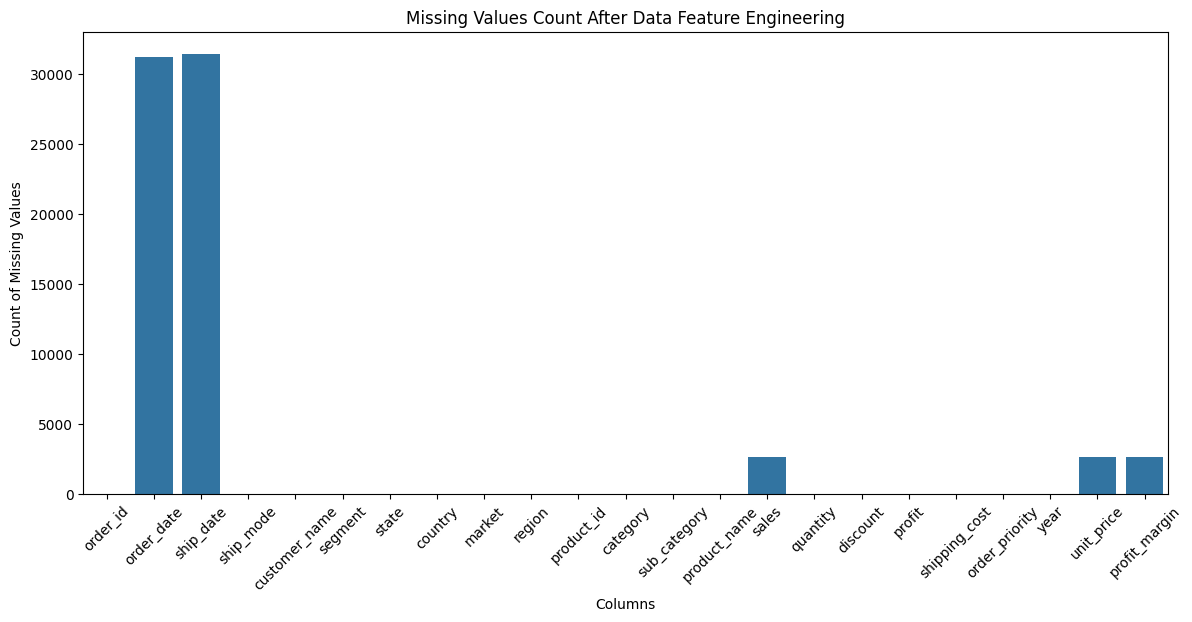

In [9]:
# Check missing values after data feature engineering
# ---- IGNORE ---
# Visualize missing values data after data feature engineering
plt.figure(figsize=(14, 6))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.title('Missing Values Count After Data Feature Engineering')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [10]:
# Handle missing values

# Imputation methods on sales, unit_price, and profit_margin columns
# 1. Impute with mean
mean_imputed_sales = df['sales'].fillna(df['sales'].mean())
mean_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].mean())
mean_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].mean())

# 2. Impute with median
median_imputed_sales = df['sales'].fillna(df['sales'].median())
median_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].median())
median_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].median())

# 3. Interpolate missing values with linear method
linear_interpolated_sales = df['sales'].interpolate(method='linear')
linear_interpolated_unit_price = df['unit_price'].interpolate(method='linear')
linear_interpolated_profit_margin = df['profit_margin'].interpolate(method='linear')

In [11]:
# Handle missing values for sales, unit_price, and profit_margin columns using linear interpolation
df['sales'] = linear_interpolated_sales
df['unit_price'] = linear_interpolated_unit_price
df['profit_margin'] = linear_interpolated_profit_margin

In [12]:
df['sales'].describe()

count    5.129000e+04
mean     1.740327e+06
std      2.090926e+06
min      0.000000e+00
25%      3.100000e+05
50%      8.500000e+05
75%      2.400000e+06
max      9.990000e+06
Name: sales, dtype: float64

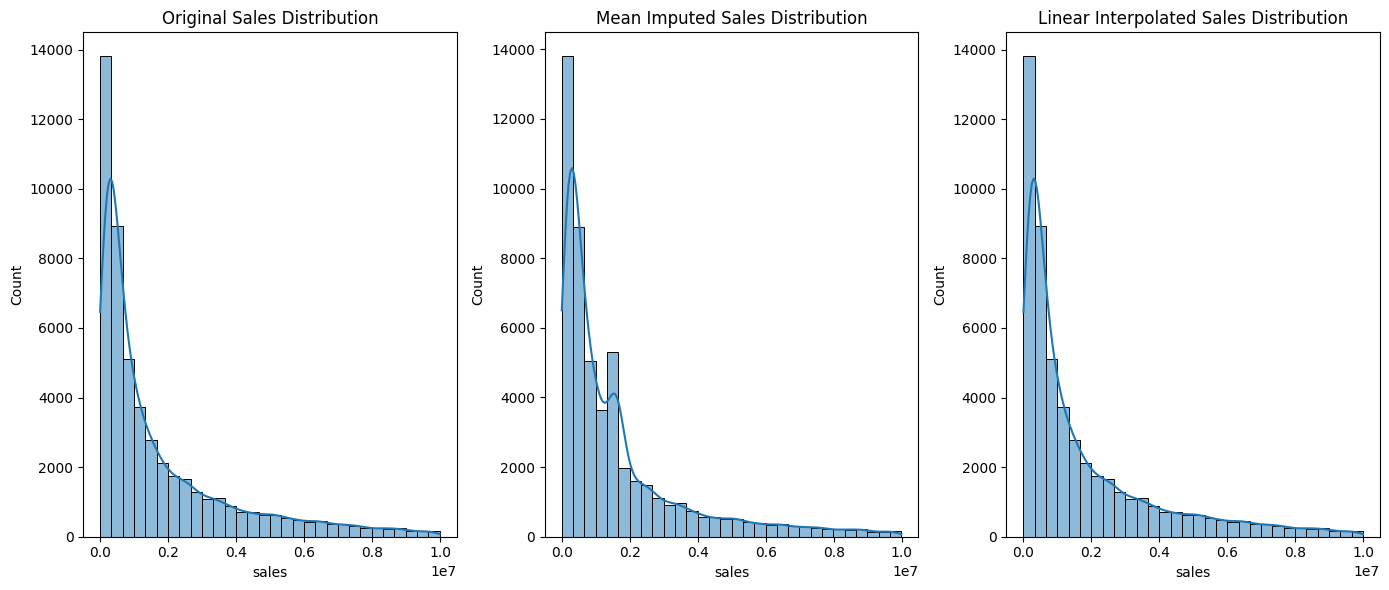

In [13]:
# visualize comparison of original sales, mean imputed sales, and linear interpolated sales
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Original Sales Distribution')
plt.subplot(1, 3, 2)
sns.histplot(mean_imputed_sales, bins=30, kde=True)
plt.title('Mean Imputed Sales Distribution')
plt.subplot(1, 3, 3)
sns.histplot(linear_interpolated_sales, bins=30, kde=True)
plt.title('Linear Interpolated Sales Distribution')
plt.tight_layout()
plt.show()

## Data Visualization

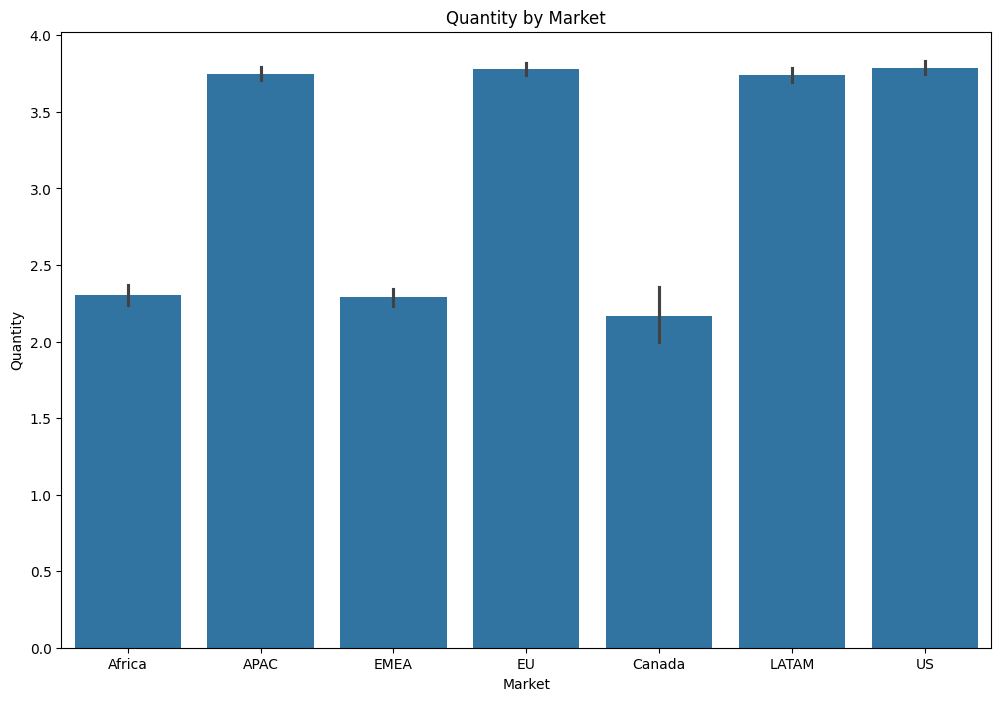

In [14]:
# Visual data for sales by category
plt.figure(figsize=(12, 8))
sns.barplot(x='market', y='quantity', data=df)
plt.title('Quantity by Market')
plt.xlabel('Market')
plt.ylabel('Quantity')
plt.show()

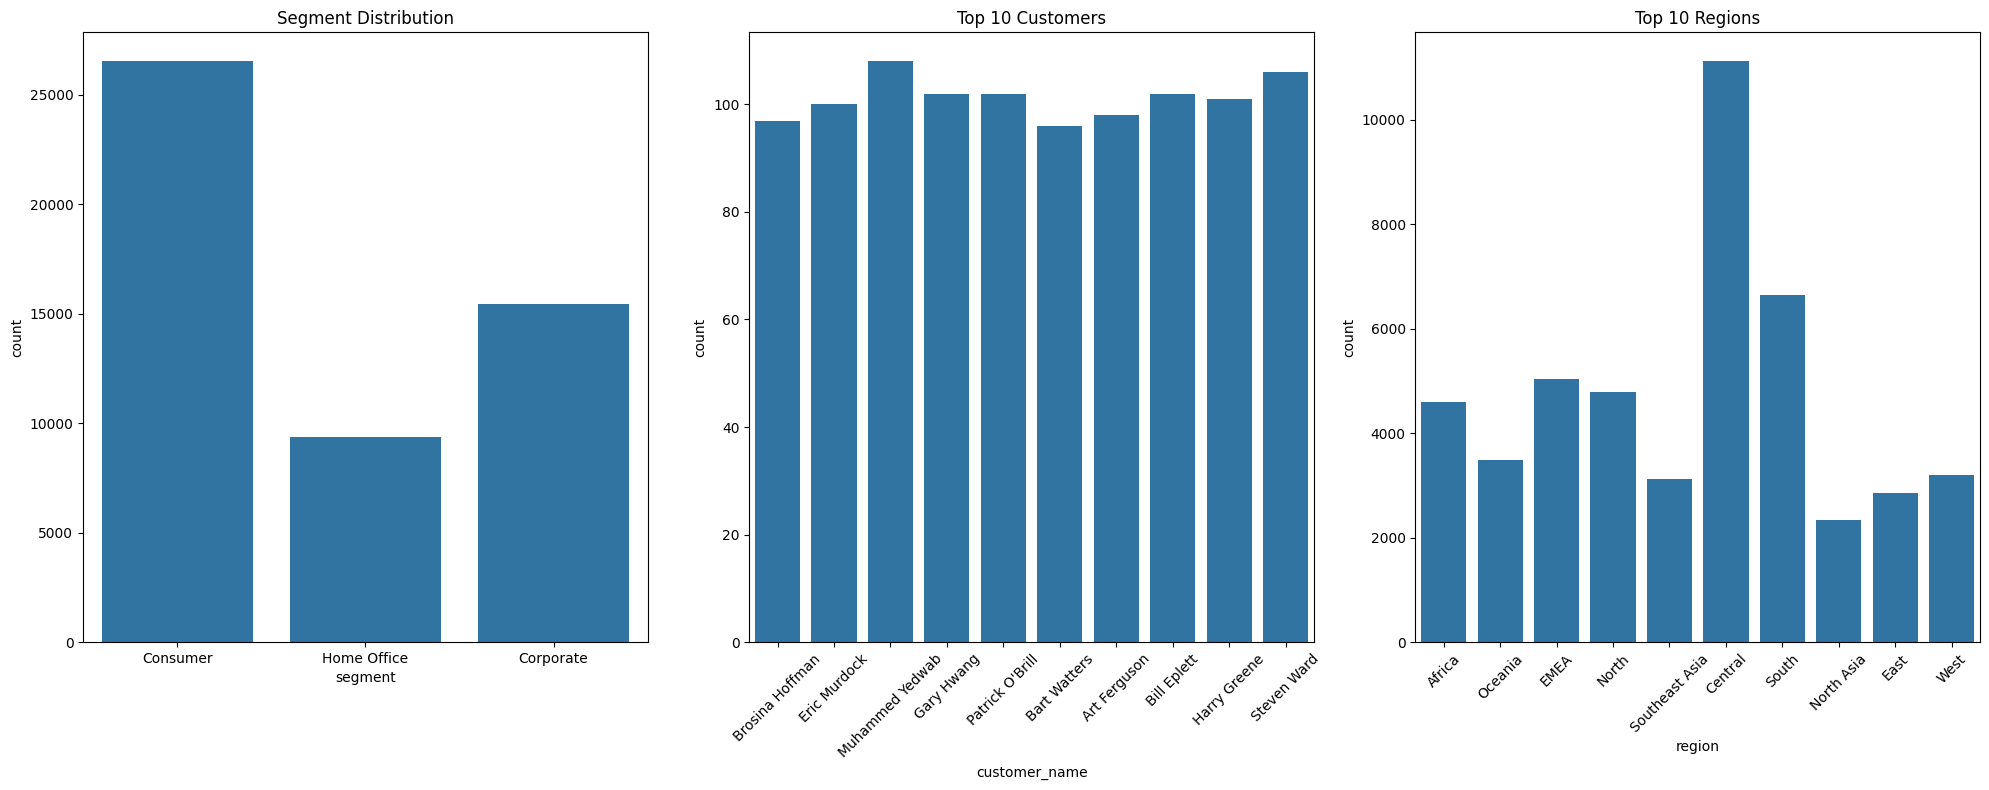

In [15]:
# Get top 10 customer_name (most frequent)
top_customers_10 = df['customer_name'].value_counts().head(10)

# Get top 10 regions (most frequent)
top_regions_10 = df['region'].value_counts().head(10)

# Data visualization for segment (user), customer_name (top 10), and region (top 10)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
sns.countplot(x='segment', data=df, ax=axes[0])
sns.countplot(x='customer_name', data=df[df['customer_name'].isin(top_customers_10.index)], ax=axes[1])
sns.countplot(x='region', data=df[df['region'].isin(top_regions_10.index)], ax=axes[2])

axes[0].set_title('Segment Distribution')
axes[1].set_title('Top 10 Customers')
axes[1].tick_params(axis='x', rotation=45)
axes[2].set_title('Top 10 Regions')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

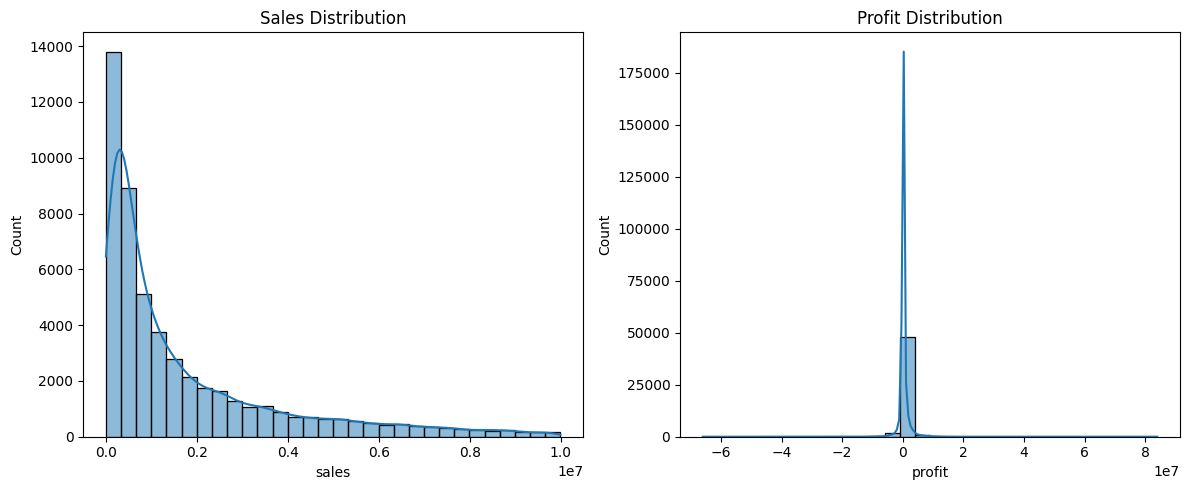

In [16]:
# Visualize sales and profit distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['profit'], bins=30, kde=True)
plt.title('Profit Distribution')
plt.tight_layout()
plt.show()

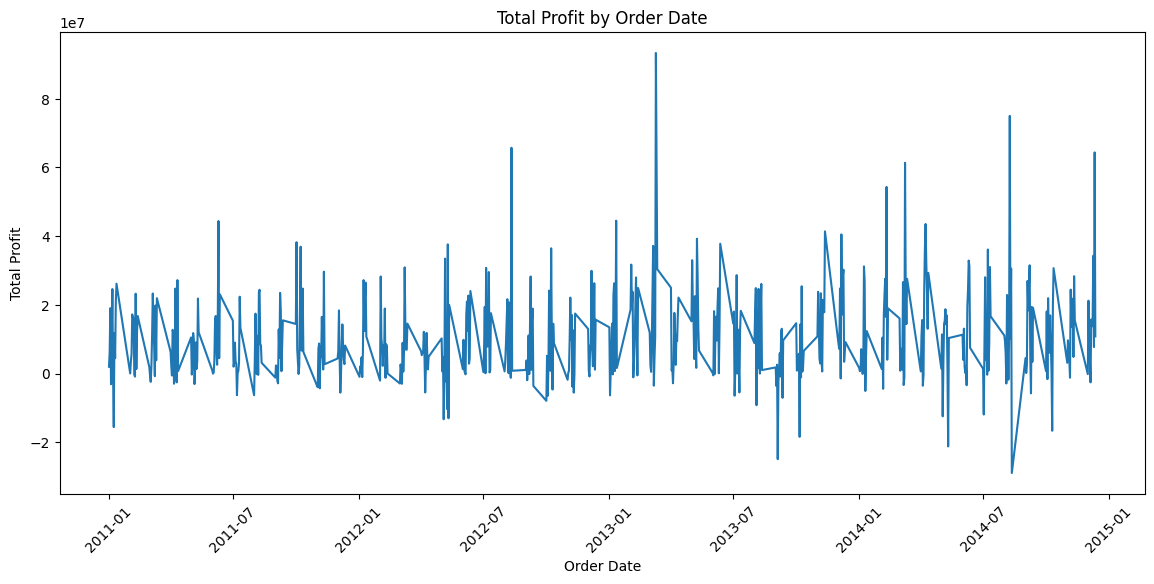

In [17]:
# Total sales by order_date
sales_by_date = df.groupby('order_date')['profit'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(sales_by_date['order_date'], sales_by_date['profit'])
plt.title('Total Profit by Order Date')
plt.xlabel('Order Date')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

## Machine learning - Deep Learning

In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans